# Analyse de la base Chinook

Objectif :
- Créer une base SQLite
- Explorer les données
- Répondre à des questions business

In [1]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'analysis.ipynb']


In [5]:
import sqlite3

db_path = "../chinook.db"   # ou juste "chinook.db" si tu veux simple

conn = sqlite3.connect(db_path)

with open("../data/Chinook_Sqlite.sql", "r", encoding="utf-8") as f:
    conn.executescript(f.read())

print("Base créée ✔")

Base créée ✔


In [6]:
print(os.listdir("../data"))

['Chinook_Sqlite.sql']


In [7]:
import pandas as pd

pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack


In [8]:
pd.read_sql_query("SELECT COUNT(*) FROM Track;", conn)

,COUNT(*)
0,3503


In [9]:
# Première requête
query = """
SELECT t.Name, COUNT(*) AS ventes
FROM InvoiceLine il
JOIN Track t ON il.TrackId = t.TrackId
GROUP BY il.TrackId
ORDER BY ventes DESC
LIMIT 10;
"""

top_tracks = pd.read_sql_query(query, conn)
top_tracks

,Name,ventes
0,Balls to the Wall,2
1,Inject The Venom,2
2,Snowballed,2
3,Overdose,2
4,Deuces Are Wild,2
5,Not The Doctor,2
6,Por Causa De Você,2
7,Welcome Home (Sanitarium),2
8,Snowblind,2
9,Cornucopia,2


In [10]:
# Top 10 des titres les plus vendus
top_tracks

,Name,ventes
0,Balls to the Wall,2
1,Inject The Venom,2
2,Snowballed,2
3,Overdose,2
4,Deuces Are Wild,2
5,Not The Doctor,2
6,Por Causa De Você,2
7,Welcome Home (Sanitarium),2
8,Snowblind,2
9,Cornucopia,2


<Axes: ylabel='Name'>

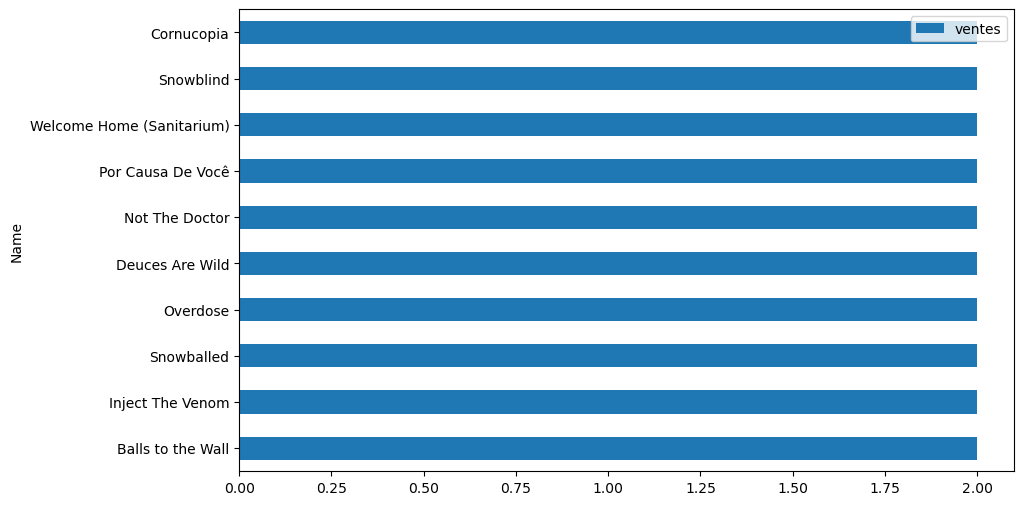

In [11]:
top_tracks.sort_values("ventes", ascending=True).plot(
    kind="barh",
    x="Name",
    y="ventes",
    figsize=(10,6)
)

In [18]:
# Revenu par pays
query = """
SELECT BillingCountry, SUM(Total) AS revenu
FROM Invoice
GROUP BY BillingCountry
ORDER BY revenu DESC;
"""

revenue_country = pd.read_sql_query(query, conn)
revenue_country

,BillingCountry,revenu
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


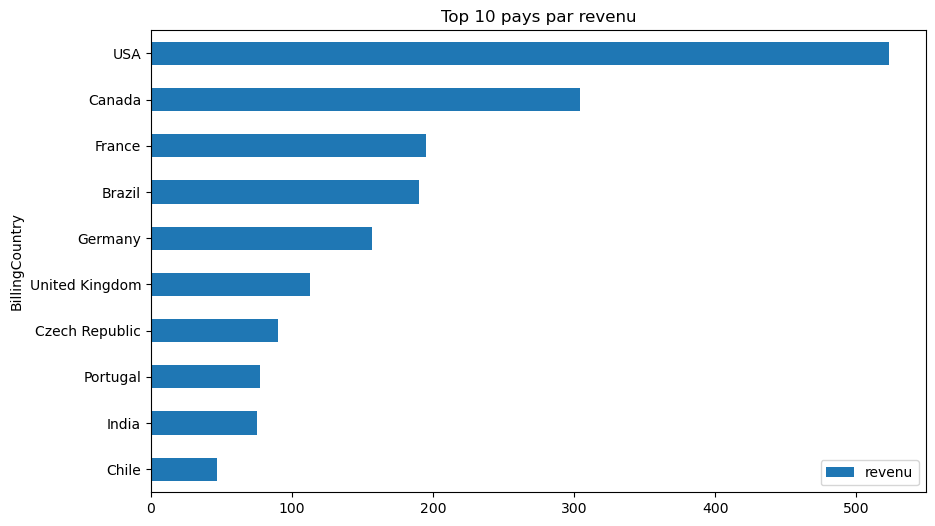

In [21]:
# Visualisation
import matplotlib.pyplot as plt

top10 = revenue_country.head(10)

top10.sort_values("revenu").plot(
    kind="barh",
    x="BillingCountry",
    y="revenu",
    figsize=(10,6)
)

plt.title("Top 10 pays par revenu")
plt.show()

In [22]:
# Meilleur vendeur
query_sales = """
SELECT 
    e.FirstName || ' ' || e.LastName AS vendeur,
    SUM(i.Total) AS ventes
FROM Employee e
JOIN Customer c ON e.EmployeeId = c.SupportRepId
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY vendeur
ORDER BY ventes DESC;
"""

top_sales = pd.read_sql_query(query_sales, conn)

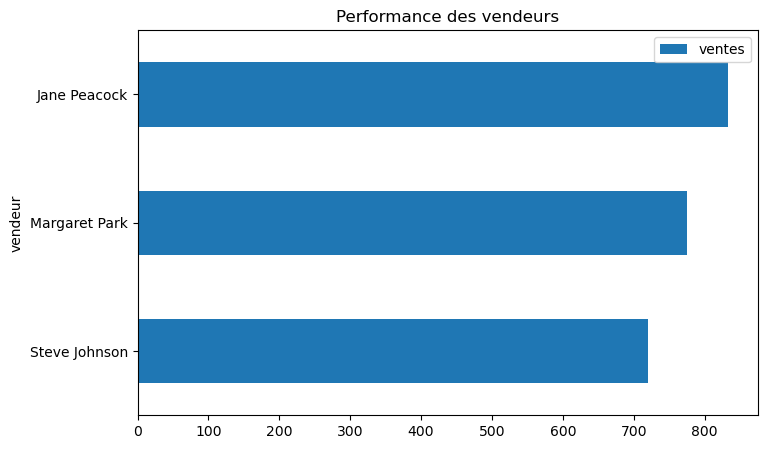

In [23]:
top_sales.sort_values("ventes").plot(
    kind="barh",
    x="vendeur",
    y="ventes",
    figsize=(8,5)
)

plt.title("Performance des vendeurs")
plt.show()